# Retail Banking Risk & Fraud Analytics Platform

# Phase 4: Model Building

## Objective

Prepare the final dataset for machine learning by encoding categorical variables, creating training and testing datasets, and building baseline fraud detection models.

In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
data = pd.read_pickle("../outputs/final_dataset.pkl")

print(data.shape)

(590540, 429)


In [3]:
X = data.drop(columns=["isFraud"])
y = data["isFraud"]

print(X.shape)
print(y.shape)

(590540, 428)
(590540,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(472432, 428)
(118108, 428)


# Baseline Random Forest Model

In [5]:
# Smaller sample for baseline model (RAM friendly)

train_sample = 100000

X_train_sample = X_train.iloc[:train_sample]
y_train_sample = y_train.iloc[:train_sample]

print(X_train_sample.shape)

(100000, 428)


In [2]:
from sklearn.ensemble import RandomForestClassifier

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [9]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [10]:
data = pd.read_pickle("../outputs/final_dataset.pkl")

print(data.shape)

(590540, 429)


In [11]:
num_cols = data.columns[data.dtypes != "object"]

for col in num_cols:
    if data[col].isnull().any():
        data[col] = data[col].fillna(data[col].median())

cat_cols = data.columns[data.dtypes == "object"]

for col in cat_cols:
    if data[col].isnull().any():
        data[col] = data[col].fillna("Unknown")

encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))

print(data.isnull().sum().sum())

0


In [12]:
X = data.drop(columns=["isFraud"])
y = data["isFraud"]

print(X.shape)
print(y.shape)

(590540, 428)
(590540,)


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(472432, 428)
(118108, 428)


In [14]:
train_sample = 100000

X_train_sample = X_train.iloc[:train_sample]
y_train_sample = y_train.iloc[:train_sample]

print(X_train_sample.shape)

(100000, 428)


In [15]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_sample, y_train_sample)

print("Model Trained Successfully!")

Model Trained Successfully!


In [16]:
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print("Prediction Completed!")

Prediction Completed!


In [17]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.9734310969621025
Precision: 0.8951548848292296
Recall   : 0.2726832809097508
F1 Score : 0.418026706231454
ROC AUC  : 0.870916405477513


In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99    113975
           1       0.90      0.27      0.42      4133

    accuracy                           0.97    118108
   macro avg       0.93      0.64      0.70    118108
weighted avg       0.97      0.97      0.97    118108



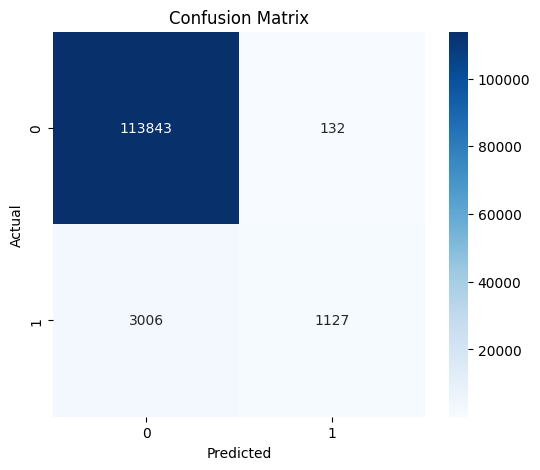

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [20]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
309,V258,0.029794
252,V201,0.029634
308,V257,0.025170
96,V45,0.024389
310,V259,0.022589
15,C1,0.022559
297,V246,0.021199
26,C12,0.020293
240,V189,0.019486
251,V200,0.019065


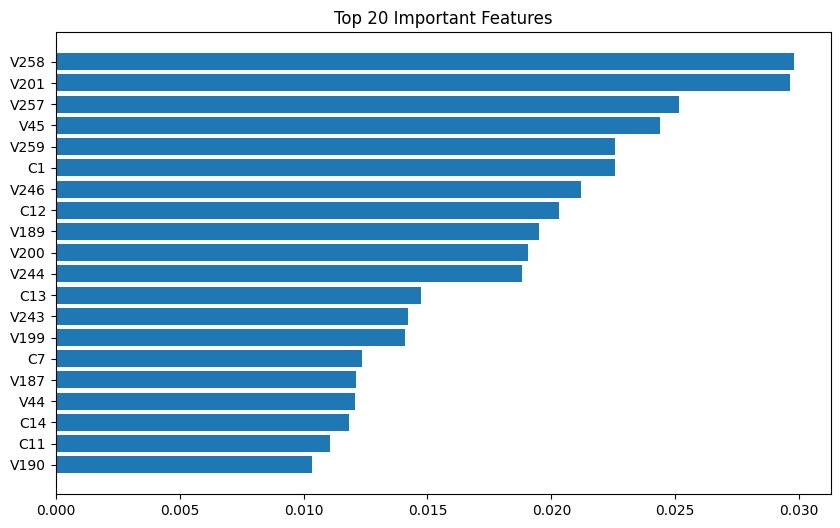

In [21]:
plt.figure(figsize=(10, 6))

plt.barh(
    importance["Feature"].head(20),
    importance["Importance"].head(20)
)

plt.gca().invert_yaxis()
plt.title("Top 20 Important Features")
plt.show()

# Model Building Observations

- Random Forest model was successfully trained on a 100,000-record sample.
- Dataset was split into 80% training and 20% testing sets.
- The model was evaluated using Accuracy, Precision, Recall, F1-score, and ROC-AUC.
- Feature importance analysis identified the most influential predictors for fraud detection.
- This baseline model will serve as a benchmark for future model improvements.